In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

#### Unión y limpieza de archivos `.parquet` provenientes de R

In [2]:
df_list = []
_msg = "Archivos agregados a la lista: "
for pqt_file in sorted(os.listdir('data/')):
    if pqt_file.endswith('.parquet'):
        df = pd.read_parquet(os.path.join('data/', pqt_file))
        _msg += f"{pqt_file.replace('.parquet', '')}, "
        df_list.append(df)

print(_msg)

Archivos agregados a la lista: base_ind_2004, base_ind_2005, base_ind_2006, base_ind_2007, base_ind_2008, base_ind_2009, base_ind_2010, base_ind_2011, base_ind_2012, base_ind_2013, base_ind_2014, base_ind_2015, base_ind_2016, base_ind_2017, base_ind_2018, base_ind_2019, base_ind_2020, base_ind_2021, base_ind_2022, base_ind_2023, base_ind_2024, base_ind_2025, 


In [3]:
base_full = pd.concat(df_list)

df_select = base_full[
    [
        "ANO4",
        "TRIMESTRE",
        "REGION",
        "AGLOMERADO",
        "PONDERA",
        "PONDII",
        "PONDIIO",
        "CH04",
        "CH06",
        "NIVEL_ED",
        "ESTADO",
        "CAT_OCUP",
        "CAT_INAC",
        "EMPLEO",
        "CH08",
        "PP07H",
        "P21",
        "P47T",
        "caes_seccion_label",
        "caes_division_label",
        "caes_eph_label",
        "CATEGORIA",
        "JERARQUIA",
    ]
]

df_select.info()

<class 'pandas.DataFrame'>
Index: 4512483 entries, 0 to 136456
Data columns (total 23 columns):
 #   Column               Dtype   
---  ------               -----   
 0   ANO4                 float64 
 1   TRIMESTRE            float64 
 2   REGION               float64 
 3   AGLOMERADO           float64 
 4   PONDERA              float64 
 5   PONDII               float64 
 6   PONDIIO              float64 
 7   CH04                 float64 
 8   CH06                 float64 
 9   NIVEL_ED             float64 
 10  ESTADO               float64 
 11  CAT_OCUP             float64 
 12  CAT_INAC             float64 
 13  EMPLEO               float64 
 14  CH08                 float64 
 15  PP07H                float64 
 16  P21                  float64 
 17  P47T                 float64 
 18  caes_seccion_label   str     
 19  caes_division_label  str     
 20  caes_eph_label       category
 21  CATEGORIA            str     
 22  JERARQUIA            str     
dtypes: category(1), float64(

In [4]:
map_sexo = {
    1: "Varon",
    2: "Mujer"
}

df_select.CH04 = df_select.CH04.map(map_sexo)

map_region = {
    1: "Gran Buenos Aires",
    40: "NOA",
    41: "NEA",
    42: "Cuyo",
    43: "Pampeana",
    44: "Patagonia"
}

df_select.REGION = df_select.REGION.map(map_region)

map_nivel_ed = {
    1: "Primario Incompleto",
    2: "Primario Completo",
    3: "Secundario Incompleto",
    4: "Secundario Completo",
    5: "Superior o Universitario Incompleto",
    6: "Superior o Universitario Completo",
    7: "Sin Instruccion",
    9: "NS/NC"
}

df_select.NIVEL_ED = df_select.NIVEL_ED.map(map_nivel_ed)

map_estado = {
    0: "Sin respuesta",
    1: "Ocupado",
    2: "Desocupado",
    3: "Inactivo",
    4: "Menor de 10 años"
}

df_select.ESTADO = df_select.ESTADO.map(map_estado)

map_cat_ocup = {
    0: "Inactivo",
    1: "Patron",
    2: "Cuenta Propia",
    3: "Obrero o empleado",
    4: "Trabajador familiar sin remuneracion",
    9: "NS/NR"
}

df_select.CAT_OCUP = df_select.CAT_OCUP.map(map_cat_ocup)

map_cat_inac = {
    0: "Ocupado",
    1: "Jubilado",
    2: "Rentista",
    3: "Estudiante",
    4: "Ama de Casa",
    5: "Menor de 6 años",
    6: "Discapacitado",
    7: "Otros"
}

df_select.CAT_INAC = df_select.CAT_INAC.map(map_cat_inac)

map_empleo = {
    1: "Formal",
    2: "Informal",
    9: "NS/NR"
}

df_select.EMPLEO = df_select.EMPLEO.map(map_empleo)

map_ch08 = {
    1: "Obra Social, PAMI",
    2: "Mutual, Prepagas, Servicio de Emergencia",
    3: "Planes y Seguros Publicos",
    4: "No paga ni le descuentan",
    9: "NS/NR",
    12: "Obra Social y Mutual, Prepegas, Servicio de Emergencia",
    13: "Obra Social y Planes y Seguros Publicos",
    23: "Mutual, Prepagas, Servicio de Emergencia y Planes y Seguros Publicos",
    123: "Obra Social, PAMI, Mutual, Prepagas, Servicio de Emergencia y Planes y Seguros Publicos"
}

df_select.CH08 = df_select.CH08.map(map_ch08)

map_pp07h = {
    0: np.nan,
    1: "Si",
    2: "No"
}

df_select.PP07H = df_select.PP07H.map(map_pp07h)

df_select["desc_ocup"] = np.where(df_select.CAT_INAC == "Ocupado", df_select.CAT_OCUP, df_select.CAT_INAC)

In [5]:
df_select.sort_values(["ANO4", "TRIMESTRE"], ascending=[True, True]).head(3)

,ANO4,TRIMESTRE,REGION,AGLOMERADO,PONDERA,PONDII,PONDIIO,CH04,CH06,NIVEL_ED,...,CH08,PP07H,P21,P47T,caes_seccion_label,caes_division_label,caes_eph_label,CATEGORIA,JERARQUIA,desc_ocup
0,2004.0,1.0,Pampeana,0.0,386.0,NaN,NaN,Varon,32.0,Superior o Universitario Incompleto,...,"Obra Social y Mutual, Prepegas, Servicio de Em...",Si,1440.0,3040.0,"SERVICIO DE TRANSPORTE, DE ALMACENAMIENTO Y DE...",SERVICIO DE TRANSPORTE TERRESTRE,NaN,"Ocupaciones de la gestión administrativa, plan...",Trabajadores asalariados,Obrero o empleado
1,2004.0,1.0,Pampeana,0.0,386.0,NaN,NaN,Mujer,30.0,Secundario Completo,...,"Obra Social y Mutual, Prepegas, Servicio de Em...",NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Ama de Casa
2,2004.0,1.0,Pampeana,0.0,386.0,NaN,NaN,Mujer,2.0,Sin Instruccion,...,"Obra Social y Mutual, Prepegas, Servicio de Em...",NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Menor de 6 años


## Recreación del índice de desempleo

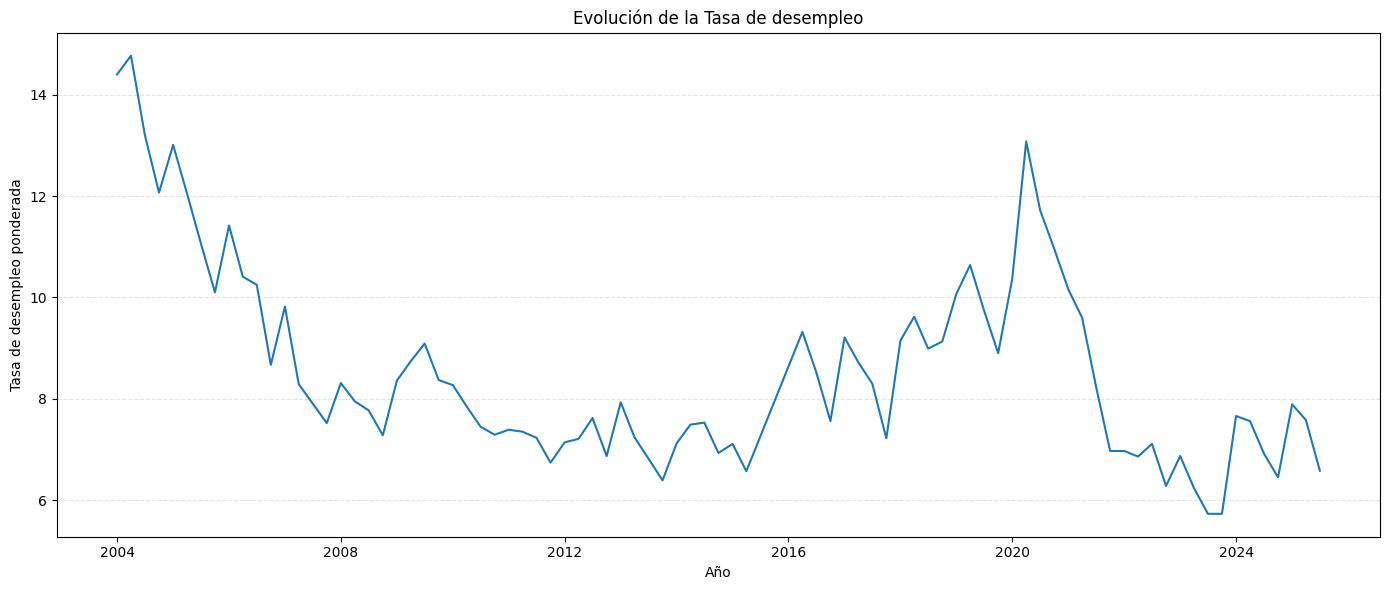

In [10]:
df_empleo = df_select.copy()

# Convertir año + trimestre a fecha real (primer mes del trimestre)
df_empleo["fecha"] = pd.to_datetime(
    df_empleo["ANO4"].astype(int).astype(str) + "-" +
    ((df_empleo["TRIMESTRE"] - 1) * 3 + 1).astype(int).astype(str) + "-01"
)

df_empleo["ocupado"] = (df_empleo["ESTADO"] == "Ocupado").astype(float)
df_empleo["desocupado"] = (df_empleo["ESTADO"] == "Desocupado").astype(float)
df_empleo["desocupado_ponderado"] = df_empleo["desocupado"] * df_empleo["PONDERA"]
df_empleo["poblacion_activa_ponderada"] = (df_empleo["ocupado"] + df_empleo["desocupado"]) * df_empleo["PONDERA"]

df_empleo_agg = (
    df_empleo
    .groupby(["fecha"], as_index=False)
    .agg({"desocupado_ponderado": "sum", "poblacion_activa_ponderada": "sum"})
    .rename(columns={"desocupado_ponderado": "desocupado_total", "poblacion_activa_ponderada": "poblacion_activa_total"})
    .assign(tasa_desempleo=lambda t: np.round(t["desocupado_total"] / t["poblacion_activa_total"]*100, 2))
)

df_empleo_agg = df_empleo_agg.sort_values(["fecha"])

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=df_empleo_agg,
    x="fecha",
    y="tasa_desempleo",
    markers=True,
    dashes=False,
    ax=ax
)

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

# Alternativa más simple si DateFormatter("%q") no está disponible en tu versión:
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax.set_title("Evolución de la Tasa de desempleo")
ax.set_ylabel("Tasa de desempleo ponderada")
ax.set_xlabel("Año")
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

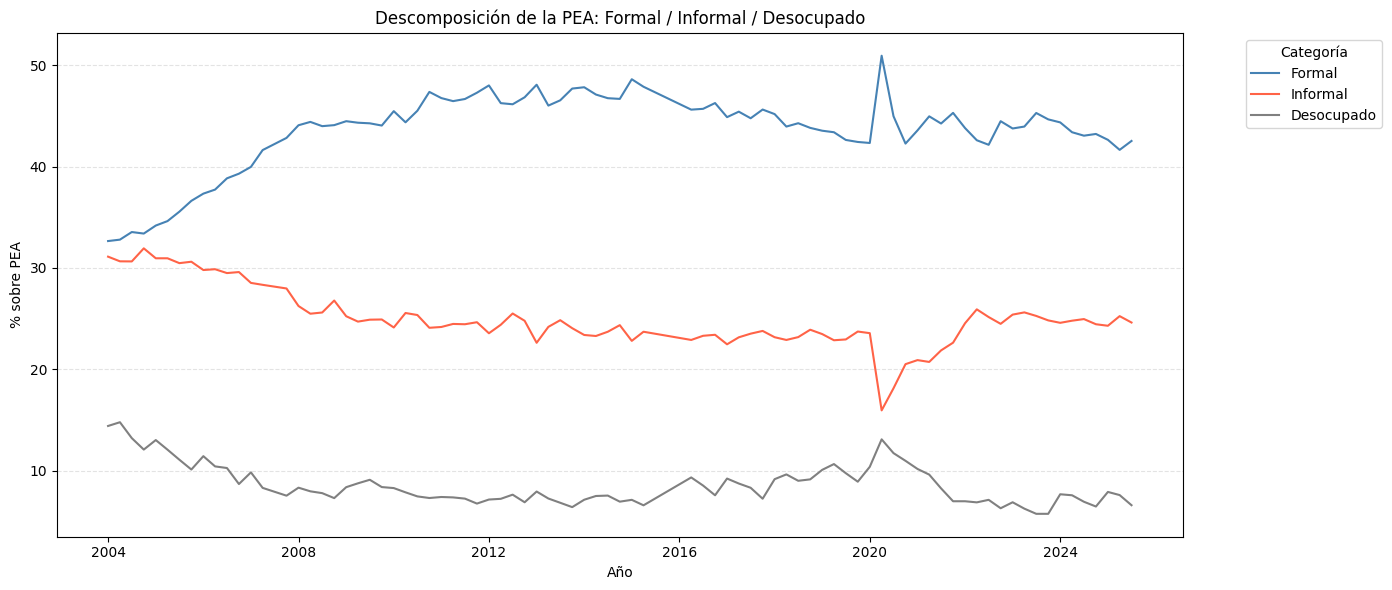

In [13]:
df_empleo = df_select.copy()

df_empleo["fecha"] = pd.to_datetime(
    df_empleo["ANO4"].astype(int).astype(str) + "-" +
    ((df_empleo["TRIMESTRE"] - 1) * 3 + 1).astype(int).astype(str) + "-01"
)

# PEA completa como denominador
df_pea = df_empleo[df_empleo["ESTADO"].isin(["Ocupado", "Desocupado"])].copy()

df_total_pea = (
    df_pea
    .groupby("fecha", as_index=False)
    .agg(pea=("PONDERA", "sum"))
)

# Cada categoría por separado
df_formal = (
    df_pea[(df_pea["ESTADO"] == "Ocupado") & (df_pea["PP07H"] == "Si")]
    .groupby("fecha", as_index=False)
    .agg(peso=("PONDERA", "sum"))
    .assign(categoria="Formal")
)

df_informal = (
    df_pea[(df_pea["ESTADO"] == "Ocupado") & (df_pea["PP07H"] == "No")]
    .groupby("fecha", as_index=False)
    .agg(peso=("PONDERA", "sum"))
    .assign(categoria="Informal")
)

df_desocupado = (
    df_pea[df_pea["ESTADO"] == "Desocupado"]
    .groupby("fecha", as_index=False)
    .agg(peso=("PONDERA", "sum"))
    .assign(categoria="Desocupado")
)

# Unir y calcular tasa sobre PEA real
df_agg = (
    pd.concat([df_formal, df_informal, df_desocupado])
    .merge(df_total_pea, on="fecha", how="left")
    .assign(tasa=lambda t: np.round(t["peso"] / t["pea"] * 100, 2))
    .sort_values(["fecha", "categoria"])
)

# Graficar
fig, ax = plt.subplots(figsize=(14, 6))

orden_colores = {"Formal": "steelblue", "Informal": "tomato", "Desocupado": "gray"}

sns.lineplot(
    data=df_agg,
    x="fecha",
    y="tasa",
    hue="categoria",
    hue_order=list(orden_colores.keys()),
    palette=orden_colores,
    markers=True,
    dashes=False,
    ax=ax
)

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

ax.set_title("Descomposición de la PEA: Formal / Informal / Desocupado")
ax.set_ylabel("% sobre PEA")
ax.set_xlabel("Año")
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend(title="Categoría", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

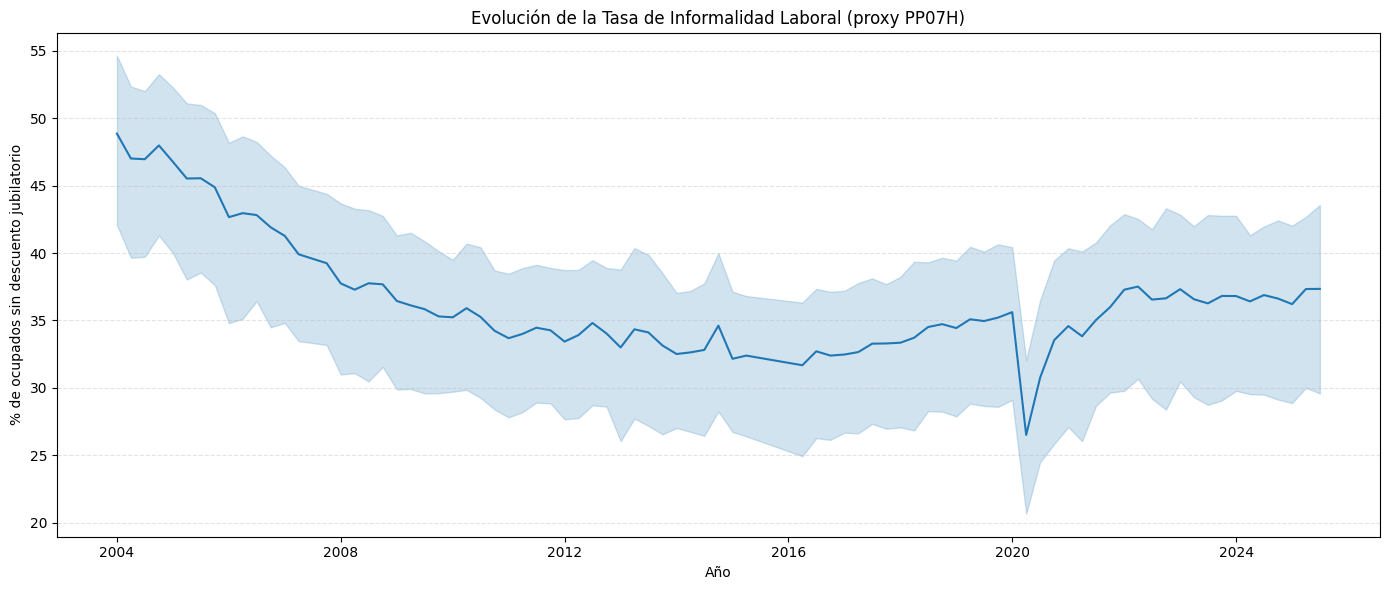

In [8]:
df_informal = df_select.copy()

# Convertir año + trimestre a fecha real
df_informal["fecha"] = pd.to_datetime(
    df_informal["ANO4"].astype(int).astype(str) + "-" +
    ((df_informal["TRIMESTRE"] - 1) * 3 + 1).astype(int).astype(str) + "-01"
)

# Filtrar solo ocupados con respuesta válida en PP07H
df_informal = df_informal[df_informal["ESTADO"] == "Ocupado"].copy()
df_informal = df_informal[df_informal["PP07H"].isin(["Si", "No"])].copy()

df_categoria_agg = (
    df_informal
    .groupby(["fecha", "PP07H", "REGION"], as_index=False)
    .agg(peso_categoria=("PONDERA", "sum"))
)

df_total_agg = (
    df_informal
    .groupby(["fecha", "REGION"], as_index=False)
    .agg(peso_total=("PONDERA", "sum"))
)

df_informal_agg = (
    df_categoria_agg
    .merge(df_total_agg, on=["fecha", "REGION"], how="left")
    .assign(tasa_informalidad=lambda t: np.round(t["peso_categoria"] / t["peso_total"] * 100, 2))
    .sort_values(["fecha", "PP07H", "REGION"])
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=df_informal_agg[df_informal_agg["PP07H"] == "No"],  # "No" = sin descuento jubilatorio = informal
    x="fecha",
    y="tasa_informalidad",
    # hue="REGION",  # descomentar para ver por región
    markers=True,
    dashes=False,
    ax=ax
)

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

ax.set_title("Evolución de la Tasa de Informalidad Laboral (proxy PP07H)")
ax.set_ylabel("% de ocupados sin descuento jubilatorio")
ax.set_xlabel("Año")
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()